In [ ]:
from google.colab import drive
import os
import shutil

# Ensure the mount point is clean
mountpoint = '/content/drive'

# Attempt to unmount first, if it's currently mounted
if 'google.colab.drive' in str(type(drive)):
    try:
        drive.flush_and_unmount()
    except ValueError:
        # Ignore if not mounted or if there's an issue with unmounting a non-existent mount
        pass
    except Exception as e:
        print(f"Warning: An unexpected error occurred during unmount: {e}")

# Explicitly remove the directory if it exists and then recreate it
if os.path.isdir(mountpoint):
    try:
        shutil.rmtree(mountpoint)
        print(f"Removed existing mount point directory: {mountpoint}")
    except OSError as e:
        print(f"Error removing mount point {mountpoint}: {e}. Trying to proceed...")

os.makedirs(mountpoint, exist_ok=True)

# Now attempt to mount
drive.mount(mountpoint, force_remount=True)

Removed existing mount point directory: /content/drive
Mounted at /content/drive


In [ ]:
!pip install monai timm einops

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [ ]:
NEW_ROI_X = np.load("/content/drive/MyDrive/Mammogram_Project/NEW_ROI_X.npy")
NEW_ROI_Y = np.load("/content/drive/MyDrive/Mammogram_Project/NEW_ROI_Y.npy")

print(NEW_ROI_X.shape)
print(NEW_ROI_Y.shape)

(3242, 128, 128, 1)
(3242, 128, 128, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, Y_train, Y_temp = train_test_split(
    NEW_ROI_X,
    NEW_ROI_Y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2593, 128, 128, 1)
Validation: (324, 128, 128, 1)
Test: (325, 128, 128, 1)


In [ ]:
import cv2
import torch
from torch.utils.data import Dataset

IMG_SIZE = 224

class MammogramDataset(Dataset):

    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = self.images[idx].squeeze()
        mask = self.masks[idx].squeeze()

        # Resize
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(
            mask,
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_NEAREST
        )

        # Convert grayscale → RGB
        image = np.stack([image, image, image], axis=0)

        # Add channel to mask
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [ ]:
from torch.utils.data import DataLoader

batch_size = 8      # SwinUNETR uses much more GPU memory

train_dataset = MammogramDataset(X_train, Y_train)
val_dataset = MammogramDataset(X_val, Y_val)
test_dataset = MammogramDataset(X_test, Y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True
)

print(len(train_loader), len(val_loader), len(test_loader))

325 41 41


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
!pip install -q monai

In [ ]:
import monai
print(monai.__version__)

1.6.0


In [ ]:
from monai.networks.nets import SwinUNETR
import inspect

print(inspect.signature(SwinUNETR))

(in_channels: 'int', out_channels: 'int', patch_size: 'int' = 2, depths: 'Sequence[int]' = (2, 2, 2, 2), num_heads: 'Sequence[int]' = (3, 6, 12, 24), window_size: 'Sequence[int] | int' = 7, qkv_bias: 'bool' = True, mlp_ratio: 'float' = 4.0, feature_size: 'int' = 24, norm_name: 'tuple | str' = 'instance', drop_rate: 'float' = 0.0, attn_drop_rate: 'float' = 0.0, dropout_path_rate: 'float' = 0.0, normalize: 'bool' = True, norm_layer: 'type[LayerNorm]' = <class 'torch.nn.modules.normalization.LayerNorm'>, patch_norm: 'bool' = False, use_checkpoint: 'bool' = False, spatial_dims: 'int' = 3, downsample: 'str | nn.Module' = 'merging', use_v2: 'bool' = False) -> 'None'


In [ ]:
from monai.networks.nets import SwinUNETR

model = SwinUNETR(
    in_channels=3,
    out_channels=1,
    feature_size=24,
    spatial_dims=2,
    use_v2=True
).to(device)

print(model)

SwinUNETR(
  (swinViT): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 24, kernel_size=(2, 2), stride=(2, 2))
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (layers1): ModuleList(
      (0): BasicLayer(
        (blocks): ModuleList(
          (0-1): 2 x SwinTransformerBlock(
            (norm1): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=24, out_features=72, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=24, out_features=24, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax): Softmax(dim=-1)
            )
            (drop_path): Identity()
            (norm2): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
            (mlp): MLPBlock(
              (linear1): Linear(in_features=24, out_features=96, bias=True)
              (linear2): Linear(in_features=96, ou

In [ ]:
import torch
import torch.nn as nn

# Dice Loss
def dice_loss(pred, target, smooth=1e-6):

    pred = torch.sigmoid(pred)

    pred = pred.contiguous().view(-1)
    target = target.contiguous().view(-1)

    intersection = (pred * target).sum()

    dice = (2. * intersection + smooth) / (
        pred.sum() + target.sum() + smooth
    )

    return 1 - dice


bce_loss = nn.BCEWithLogitsLoss()


def total_loss(pred, target):
    return bce_loss(pred, target) + dice_loss(pred, target)

print("Loss Loaded Successfully!")

Loss Loaded Successfully!


In [ ]:
def calculate_metrics(pred, target, smooth=1e-6):

    pred = (torch.sigmoid(pred) > 0.5).float()

    pred = pred.view(-1)
    target = target.view(-1)

    TP = (pred * target).sum()
    TN = ((1-pred)*(1-target)).sum()
    FP = (pred*(1-target)).sum()
    FN = ((1-pred)*target).sum()

    accuracy = (TP + TN) / (TP + TN + FP + FN + smooth)

    precision = TP / (TP + FP + smooth)

    recall = TP / (TP + FN + smooth)

    f1 = 2 * precision * recall / (precision + recall + smooth)

    iou = TP / (TP + FP + FN + smooth)

    dice = (2 * TP) / (2 * TP + FP + FN + smooth)

    return (
        accuracy.item(),
        precision.item(),
        recall.item(),
        f1.item(),
        iou.item(),
        dice.item()
    )

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.amp import GradScaler

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

scaler = GradScaler("cuda")

In [ ]:
import os

save_dir = "/content/drive/MyDrive/SwinUNETR"

os.makedirs(save_dir, exist_ok=True)

best_model_path = os.path.join(
    save_dir,
    "best_swinunetr.pth"
)

checkpoint_path = os.path.join(
    save_dir,
    "checkpoint_swinunetr.pth"
)

In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "val_iou": [],
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
}

In [ ]:
from tqdm import tqdm
import torch
from torch.amp import autocast

num_epochs = 50

best_dice = 0.0
patience = 8
counter = 0

for epoch in range(num_epochs):

    ##################################
    # TRAIN
    ##################################
    model.train()

    train_loss = 0.0
    train_dice = 0.0

    train_bar = tqdm(train_loader)

    for images, masks in train_bar:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast("cuda"):

            outputs = model(images)
            loss = total_loss(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        _, _, _, _, _, dice = calculate_metrics(outputs, masks)

        train_dice += dice

        train_bar.set_description(f"Epoch {epoch+1}/{num_epochs}")
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)

    ##################################
    # VALIDATION
    ##################################

    model.eval()

    val_loss = 0.0
    val_acc = 0.0
    val_precision = 0.0
    val_recall = 0.0
    val_f1 = 0.0
    val_iou = 0.0
    val_dice = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            with autocast("cuda"):

                outputs = model(images)
                loss = total_loss(outputs, masks)

            val_loss += loss.item()

            acc, prec, rec, f1, iou, dice = calculate_metrics(
                outputs,
                masks
            )

            val_acc += acc
            val_precision += prec
            val_recall += rec
            val_f1 += f1
            val_iou += iou
            val_dice += dice

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)
    val_precision /= len(val_loader)
    val_recall /= len(val_loader)
    val_f1 /= len(val_loader)
    val_iou /= len(val_loader)
    val_dice /= len(val_loader)

    ##################################
    # Scheduler
    ##################################

    scheduler.step(val_dice)

    ##################################
    # Save History
    ##################################

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["val_iou"].append(val_iou)

    history["accuracy"].append(val_acc)
    history["precision"].append(val_precision)
    history["recall"].append(val_recall)
    history["f1"].append(val_f1)

    ##################################
    # Print Results
    ##################################

    print("\n" + "=" * 60)
    print(f"Epoch {epoch+1}/{num_epochs}")

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Train Dice      : {train_dice:.4f}")

    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Dice : {val_dice:.4f}")
    print(f"Validation IoU  : {val_iou:.4f}")

    print(f"Accuracy        : {val_acc:.4f}")
    print(f"Precision       : {val_precision:.4f}")
    print(f"Recall          : {val_recall:.4f}")
    print(f"F1 Score        : {val_f1:.4f}")

    ##################################
    # Save Best Model
    ##################################

    if val_dice > best_dice:

        best_dice = val_dice
        counter = 0

        torch.save(model.state_dict(), best_model_path)

        torch.save({

            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_dice": best_dice,
            "history": history

        }, checkpoint_path)

        print("✅ Best Model Saved!")

    else:
        counter += 1

    ##################################
    # Early Stopping
    ##################################

    if counter >= patience:
        print("\n🛑 Early stopping triggered!")
        break


print("\n🎉 Training Finished!")
print(f"Best Validation Dice : {best_dice:.4f}")

Epoch 1/50: 100%|██████████| 325/325 [00:48<00:00,  6.68it/s, loss=0.6633]



Epoch 1/50
Train Loss      : 0.9751
Train Dice      : 0.6533
Validation Loss : 0.8197
Validation Dice : 0.7122
Validation IoU  : 0.5563
Accuracy        : 0.9479
Precision       : 0.6217
Recall          : 0.8503
F1 Score        : 0.7122
✅ Best Model Saved!


Epoch 2/50: 100%|██████████| 325/325 [00:46<00:00,  6.99it/s, loss=0.6356]



Epoch 2/50
Train Loss      : 0.7548
Train Dice      : 0.7214
Validation Loss : 0.6999
Validation Dice : 0.7268
Validation IoU  : 0.5744
Accuracy        : 0.9539
Precision       : 0.6722
Recall          : 0.8050
F1 Score        : 0.7268
✅ Best Model Saved!


Epoch 3/50: 100%|██████████| 325/325 [00:46<00:00,  7.05it/s, loss=0.5893]


...


Epoch 11/50
Train Loss      : 0.2149
Train Dice      : 0.8937
Validation Loss : 0.4363
Validation Dice : 0.7493
Validation IoU  : 0.6030
Accuracy        : 0.9608
Precision       : 0.7427
Recall          : 0.7657
F1 Score        : 0.7493


Epoch 12/50: 100%|██████████| 325/325 [00:45<00:00,  7.07it/s, loss=0.1631]



Epoch 12/50
Train Loss      : 0.1973
Train Dice      : 0.9018
Validation Loss : 0.4414
Validation Dice : 0.7477
Validation IoU  : 0.6010
Accuracy        : 0.9598
Precision       : 0.7278
Recall          : 0.7800
F1 Score        : 0.7477


Epoch 13/50: 100%|██████████| 325/325 [00:45<00:00,  7.11it/s, loss=0.4021]



Epoch 13/50
Train Loss      : 0.1833
Train Dice      : 0.9081
Validation Loss : 0.4413
Validation Dice : 0.7473
Validation IoU  : 0.6003
Accuracy        : 0.9608
Precision       : 0.7480
Recall          : 0.7561
F1 Score        : 0.7473

🛑 Early stopping triggered!

🎉 Training Finished!
Best Validation Dice : 0.7523


In [ ]:
import torch

checkpoint = torch.load(best_model_path, map_location=device)

model.load_state_dict(checkpoint)

model.to(device)
model.eval()

print("✅ Best SwinUNETR model loaded!")

✅ Best SwinUNETR model loaded!


In [ ]:
model.eval()

test_loss = 0
test_acc = 0
test_precision = 0
test_recall = 0
test_f1 = 0
test_iou = 0
test_dice = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = total_loss(outputs, masks)
        test_loss += loss.item()

        acc, prec, rec, f1, iou, dice = calculate_metrics(outputs, masks)

        test_acc += acc
        test_precision += prec
        test_recall += rec
        test_f1 += f1
        test_iou += iou
        test_dice += dice

# Average metrics
test_loss /= len(test_loader)
test_acc /= len(test_loader)
test_precision /= len(test_loader)
test_recall /= len(test_loader)
test_f1 /= len(test_loader)
test_iou /= len(test_loader)
test_dice /= len(test_loader)

print("\n========== Test Results ==========")
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Dice      : {test_dice:.4f}")
print(f"Test IoU       : {test_iou:.4f}")
print(f"Accuracy       : {test_acc:.4f}")
print(f"Precision      : {test_precision:.4f}")
print(f"Recall         : {test_recall:.4f}")
print(f"F1 Score       : {test_f1:.4f}")


========== Test Results ==========
Test Loss      : 0.5075
Test Dice      : 0.7408
Test IoU       : 0.5943
Accuracy       : 0.9565
Precision      : 0.6975
Recall         : 0.8031
F1 Score       : 0.7408


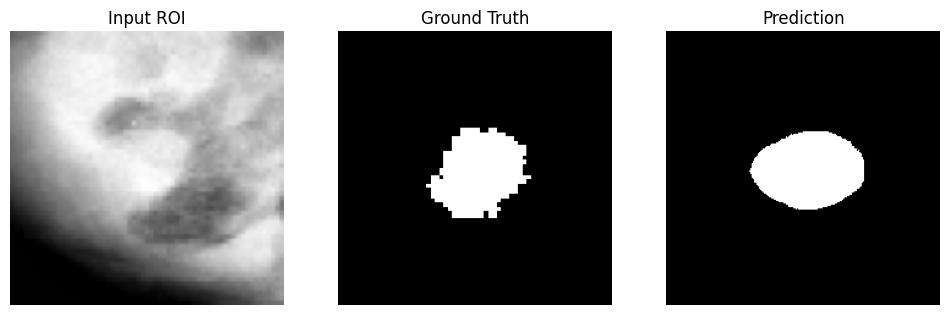

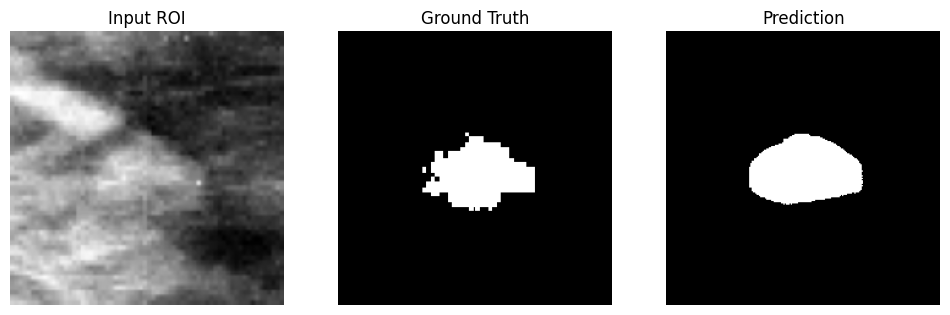

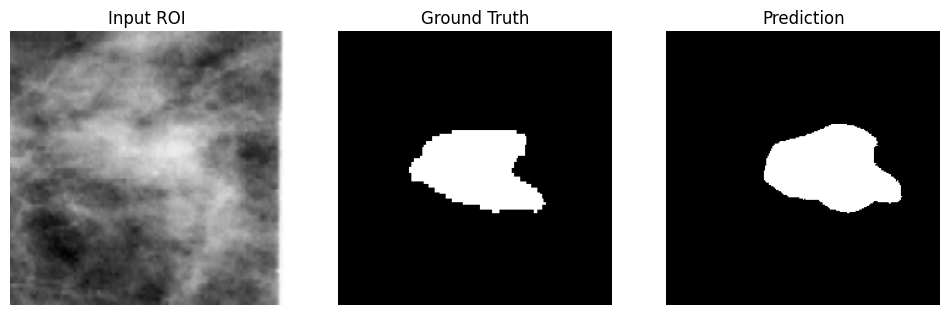

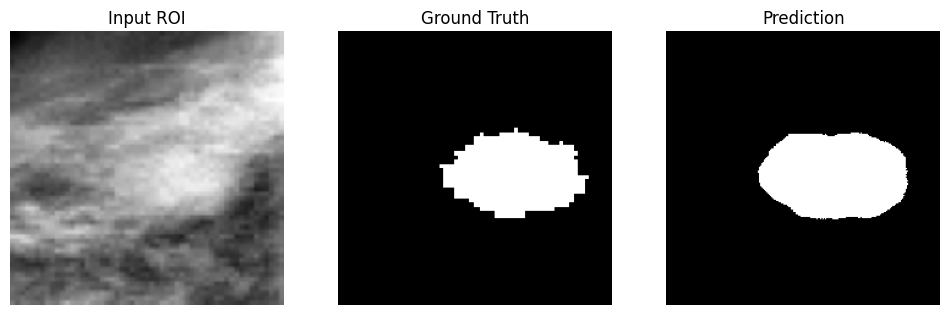

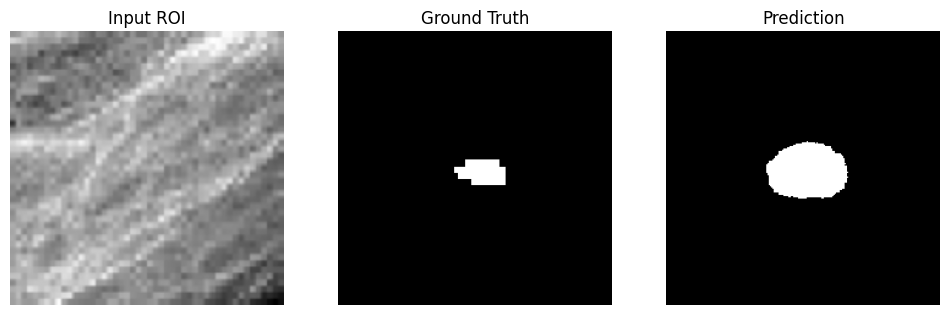

In [ ]:
import matplotlib.pyplot as plt

model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = (torch.sigmoid(outputs) > 0.5).float()

num_images = 5

for i in range(num_images):

    plt.figure(figsize=(12,4))

    # Input
    plt.subplot(1,3,1)
    plt.imshow(images[i].cpu().permute(1,2,0)[:,:,0], cmap="gray")
    plt.title("Input ROI")
    plt.axis("off")

    # Ground Truth
    plt.subplot(1,3,2)
    plt.imshow(masks[i].cpu().squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(1,3,3)
    plt.imshow(preds[i].cpu().squeeze(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

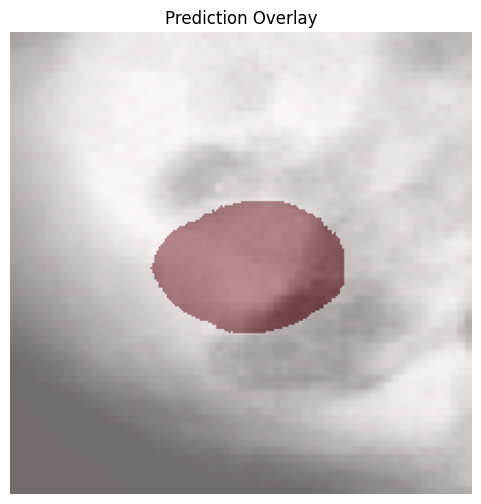

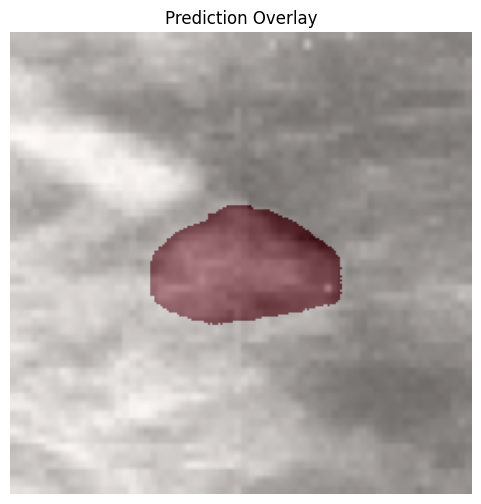

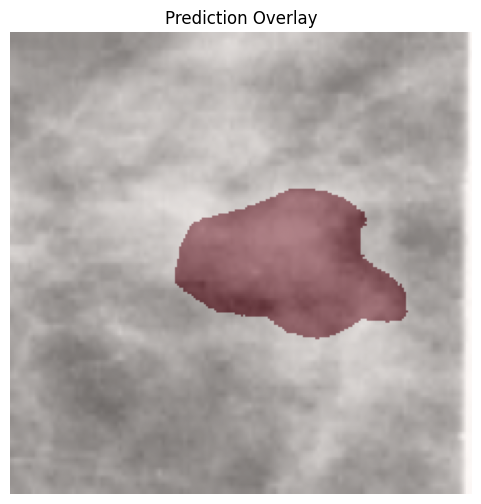

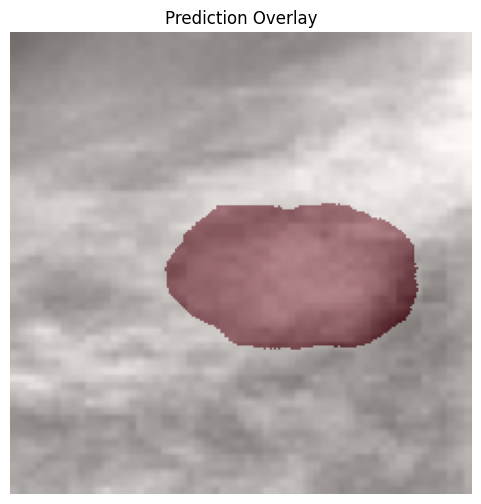

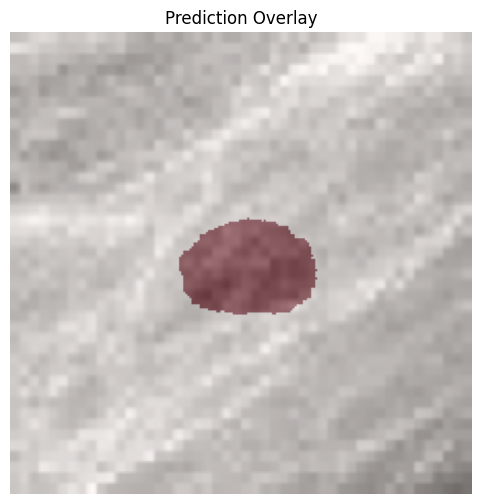

In [ ]:
for i in range(5):

    img = images[i].cpu().permute(1,2,0)[:,:,0].numpy()
    pred = preds[i].cpu().squeeze().numpy()

    plt.figure(figsize=(6,6))

    plt.imshow(img, cmap="gray")
    plt.imshow(pred, cmap="Reds", alpha=0.45)

    plt.title("Prediction Overlay")
    plt.axis("off")

    plt.show()

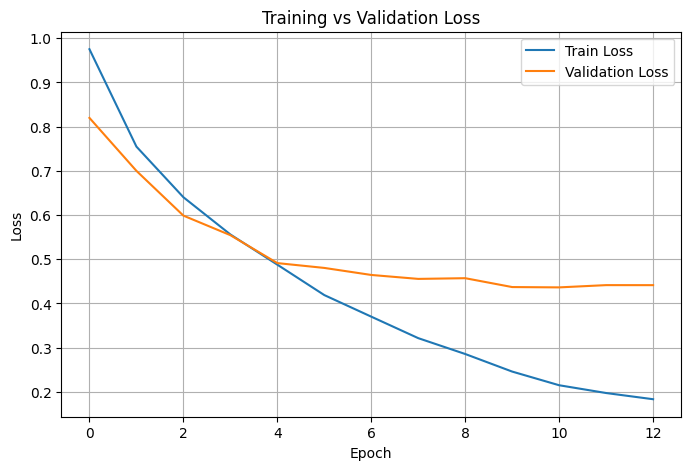

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

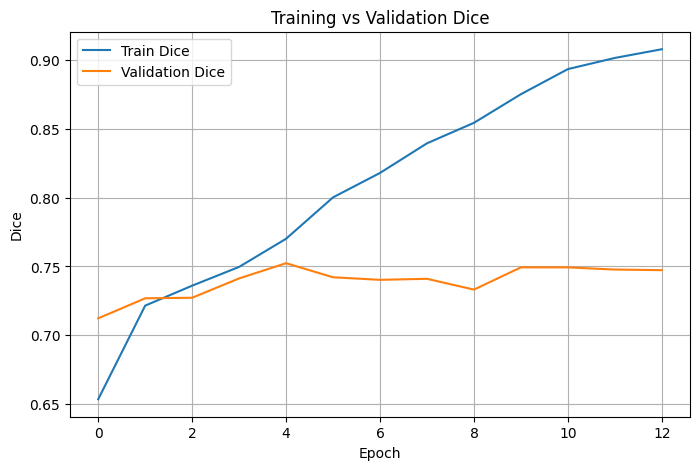

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history["train_dice"], label="Train Dice")
plt.plot(history["val_dice"], label="Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Training vs Validation Dice")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame({

    "Metric":[
        "Loss",
        "Dice",
        "IoU",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Train":[
        min(history["train_loss"]),
        max(history["train_dice"]),
        "-",
        "-",
        "-",
        "-",
        "-"
    ],

    "Validation":[
        min(history["val_loss"]),
        max(history["val_dice"]),
        max(history["val_iou"]),
        max(history["accuracy"]),
        max(history["precision"]),
        max(history["recall"]),
        max(history["f1"])
    ],

    "Test":[
        test_loss,
        test_dice,
        test_iou,
        test_acc,
        test_precision,
        test_recall,
        test_f1
    ]

})

results = results.round(4)

display(results)

,Metric,Train,Validation,Test
0,Loss,0.183282,0.4363,0.5075
1,Dice,0.908123,0.7523,0.7408
2,IoU,-,0.6067,0.5943
3,Accuracy,-,0.9608,0.9565
4,Precision,-,0.7616,0.6975
5,Recall,-,0.8683,0.8031
6,F1 Score,-,0.7523,0.7408
